In [2]:
import numpy as np
import pandas as pd

In [3]:
!gdown 1SWUXaC78y2lnahVnUwBPmyXOicJW41Po

Downloading...
From: https://drive.google.com/uc?id=1SWUXaC78y2lnahVnUwBPmyXOicJW41Po
To: /content/Country-data.csv
100% 9.23k/9.23k [00:00<00:00, 20.3MB/s]


In [4]:
country_data = pd.read_csv('Country-data.csv')

country_data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values and data types
print("--- Data Info ---")
display(country_data.info())

# Statistical summary
print("\n--- Statistical Summary ---")
display(country_data.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None


--- Statistical Summary ---


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


---
---

### **Data Preprocessing & EDA**

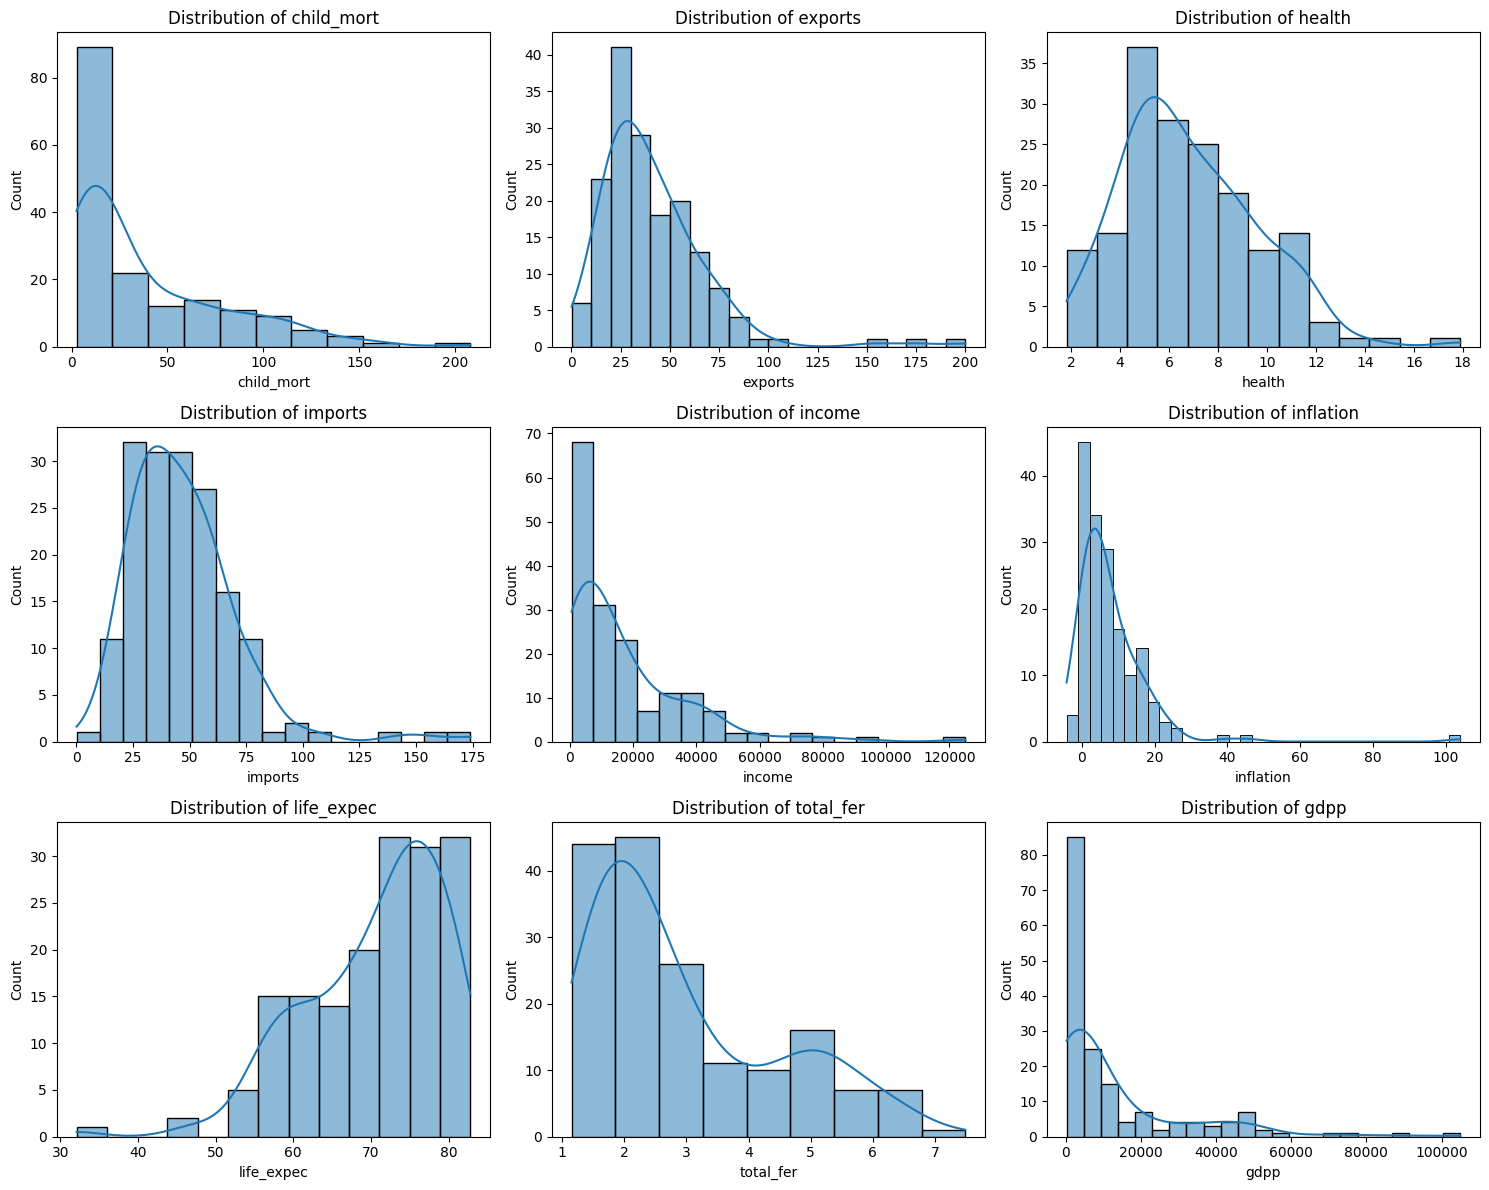

In [6]:
# Visualize distributions of key features
features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

plt.figure(figsize=(15, 12))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(country_data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

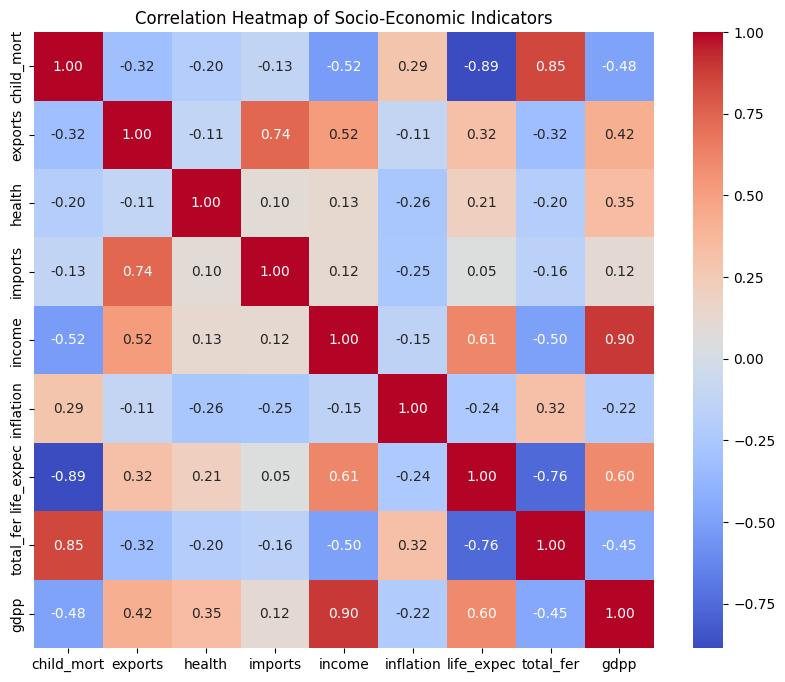

In [7]:
# Correlation heatmap to identify relationships
plt.figure(figsize=(10, 8))
sns.heatmap(country_data[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Socio-Economic Indicators')
plt.show()

---
---

### **Feature Scaling**

In [8]:
# Outlier Treatment: Using capping (percentile) method to handle extreme values
# This helps in preventing clusters from being dominated by extreme outliers

country_data_clean = country_data.copy()
for col in features:
    q1 = country_data_clean[col].quantile(0.05)
    q3 = country_data_clean[col].quantile(0.95)
    country_data_clean[col] = country_data_clean[col].clip(lower=q1, upper=q3)

print("Outliers have been capped at 5th and 95th percentiles.")

Outliers have been capped at 5th and 95th percentiles.


/tmp/ipykernel_2130/887244674.py:8: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  country_data_clean[col] = country_data_clean[col].clip(lower=q1, upper=q3)


In [9]:
from sklearn.preprocessing import StandardScaler

# Scaling the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(country_data_clean[features])

# Convert to DataFrame for easier inspection
country_data_scaled = pd.DataFrame(data_scaled, columns=features)
print("Data scaling complete. Here is the head of the scaled data:")
display(country_data_scaled.head())

Data scaling complete. Here is the head of the scaled data:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.479588,-1.371444,0.322232,-0.025440,-0.960575,0.387667,-1.825310,2.020718,-0.757874
1,-0.560024,-0.570493,-0.086218,0.177314,-0.395590,-0.404004,0.682454,-0.887331,-0.523775
2,-0.263504,-0.045941,-1.030017,-0.765221,-0.193907,1.452825,0.707406,-0.022587,-0.499286
3,2.194560,1.159521,-1.553469,-0.135037,-0.669255,2.215708,-1.338729,2.049310,-0.560839
4,-0.734610,0.312167,-0.292427,0.741740,0.227115,-0.891802,0.744836,-0.552591,0.012991


---
---

### **Clustering with K-Means**

#### **K-means clustering on just scaled data**

In [10]:
from sklearn.cluster import KMeans

# Based on the plots, let's proceed with an optimal number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, max_iter=50, random_state=42)
kmeans.fit(data_scaled)

# Assigning cluster labels back to the original data
country_data['cluster_id'] = kmeans.labels_
print("K-Means clustering with k=3 completed.")
display(country_data.groupby('cluster_id')[features].mean())

K-Means clustering with k=3 completed.


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_id,,,,,,,,,
0,90.035294,27.790176,6.225686,41.399331,3873.000000,11.932255,59.856863,4.833529,1843.529412
1,5.237838,58.097297,8.782973,51.281081,45056.756757,2.588432,79.956757,1.755676,42102.702703
2,20.322785,41.750633,6.275190,48.378481,12639.746835,7.534797,73.059494,2.289114,6496.126582


#### **Determining optimal clusters using Elbow and Silhouette methods (scaled data)**

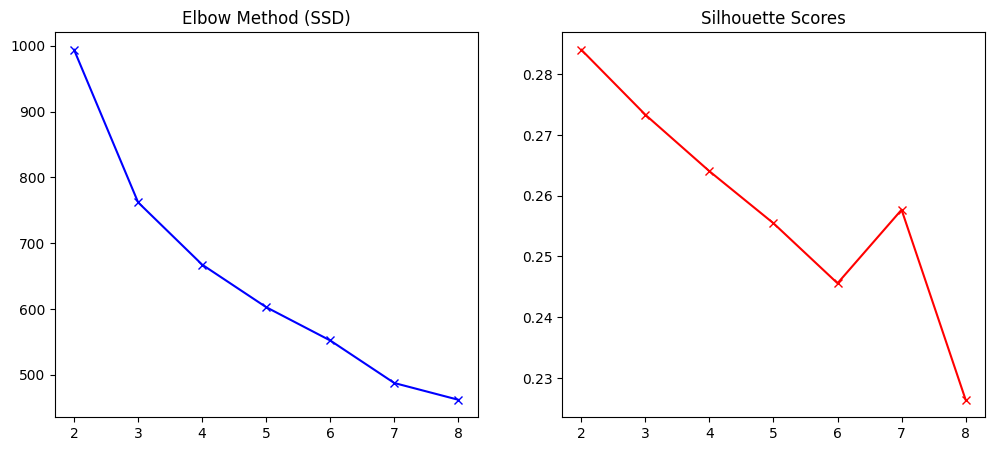

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Determining optimal clusters using Elbow and Silhouette methods
ssd = []
silhouette_scores = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(data_scaled)
    ssd.append(kmeans.inertia_)

    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting Elbow and Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, ssd, 'bx-')
plt.title('Elbow Method (SSD)')

plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, 'rx-')
plt.title('Silhouette Scores')
plt.show()

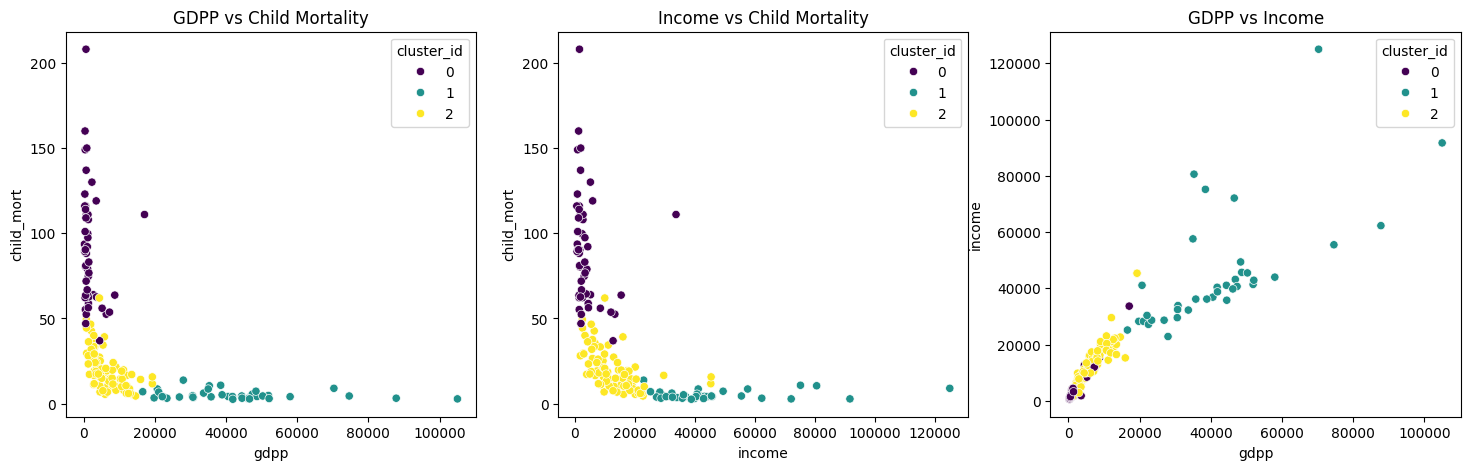

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the clusters using key socio-economic metrics
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=country_data, x='gdpp', y='child_mort', hue='cluster_id', palette='viridis')
plt.title('GDPP vs Child Mortality')

plt.subplot(1, 3, 2)
sns.scatterplot(data=country_data, x='income', y='child_mort', hue='cluster_id', palette='viridis')
plt.title('Income vs Child Mortality')

plt.subplot(1, 3, 3)
sns.scatterplot(data=country_data, x='gdpp', y='income', hue='cluster_id', palette='viridis')
plt.title('GDPP vs Income')

plt.show()

In [13]:
# Filtering countries in Cluster 0 (The high-priority group)
priority_countries = country_data[country_data['cluster_id'] == 0].sort_values(by=['gdpp', 'income', 'child_mort'], ascending=[True, True, False])

print(f'Number of countries identified in the priority cluster: {len(priority_countries)}')
print('\nTop 10 countries in dire need of development funds:')
display(priority_countries[['country', 'child_mort', 'income', 'gdpp']].head(10))

Number of countries identified in the priority cluster: 51

Top 10 countries in dire need of development funds:


,country,child_mort,income,gdpp
26,Burundi,93.6,764,231
88,Liberia,89.3,700,327
37,"Congo, Dem. Rep.",116.0,609,334
112,Niger,123.0,814,348
132,Sierra Leone,160.0,1220,399
93,Madagascar,62.2,1390,413
106,Mozambique,101.0,918,419
31,Central African Republic,149.0,888,446
94,Malawi,90.5,1030,459
50,Eritrea,55.2,1420,482


In [14]:
# Filtering countries in Cluster 1 (The highly developed group)
cluster_1_countries = country_data[country_data['cluster_id'] == 1].sort_values(by=['gdpp', 'income'], ascending=[False, False])

print(f"Number of countries identified in Cluster 1: {len(cluster_1_countries)}")
print("\nTop 10 countries in Cluster 1 (sorted by highest GDP and Income):")
display(cluster_1_countries[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(10))

Number of countries identified in Cluster 1: 37

Top 10 countries in Cluster 1 (sorted by highest GDP and Income):


,country,child_mort,income,gdpp,life_expec
91,Luxembourg,2.8,91700,105000,81.3
114,Norway,3.2,62300,87800,81.0
145,Switzerland,4.5,55500,74600,82.2
123,Qatar,9.0,125000,70300,79.5
44,Denmark,4.1,44000,58000,79.5
144,Sweden,3.0,42900,52100,81.5
7,Australia,4.8,41400,51900,82.0
110,Netherlands,4.5,45500,50300,80.7
73,Ireland,4.2,45700,48700,80.4
159,United States,7.3,49400,48400,78.7


---
---

### **Dimensionality Reduction (PCA)**

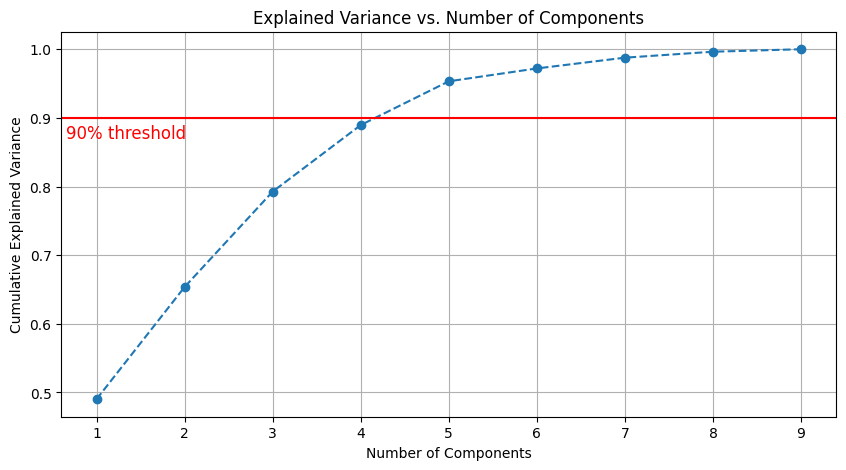

Cumulative variance explained by first 4 components: 0.89


In [15]:
from sklearn.decomposition import PCA

# Applying PCA
pca = PCA(random_state=42)
pca.fit(data_scaled)

# Calculating Cumulative Variance
var_cum = np.cumsum(pca.explained_variance_ratio_)

# Plotting Explained Variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(var_cum) + 1), var_cum, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.65, 0.87, '90% threshold', color = 'red', fontsize = 12)
plt.grid()
plt.show()

print(f"Cumulative variance explained by first 4 components: {var_cum[3]:.2f}")

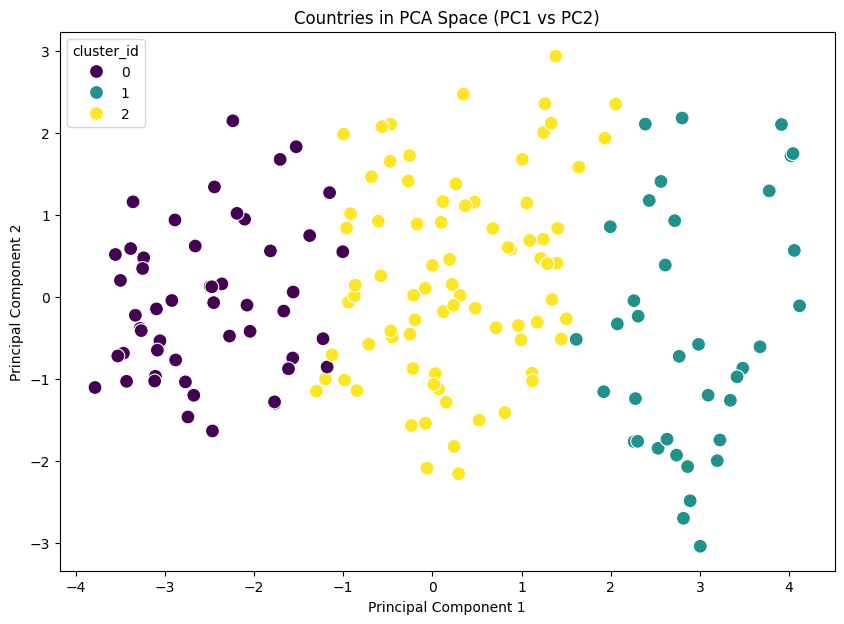

In [16]:
# Using 4 components as they explain ~89% of the variance
pca_final = PCA(n_components=4, random_state=42)
data_pca = pca_final.fit_transform(data_scaled)

# Create a dataframe for PCA components
df_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['cluster_id'] = country_data['cluster_id']
df_pca['country'] = country_data['country']

# Visualizing PC1 vs PC2
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster_id', data=df_pca, palette='viridis', s=100)
plt.title('Countries in PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [17]:
# Examining Component Loadings
loadings = pd.DataFrame(pca_final.components_.T, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=features)
print("Principal Component Loadings (weights of original features):")
display(loadings)

Principal Component Loadings (weights of original features):


,PC1,PC2,PC3,PC4
child_mort,-0.421623,0.032585,0.094262,0.387864
exports,0.232156,0.599838,-0.295282,0.252625
health,0.181381,-0.191686,0.646498,0.283765
imports,0.094524,0.729981,0.283589,0.012585
income,0.410887,-0.110986,-0.198015,0.419843
inflation,-0.225176,-0.079882,-0.590478,0.169649
life_expec,0.431881,-0.129883,-0.113004,-0.225216
total_fer,-0.406693,0.008781,0.060062,0.446607
gdpp,0.393765,-0.184042,-0.035916,0.499832


### **Dimensionality Reduction: PCA Observations & Summary**

#### **1. Component Selection**
- The Scree Plot (Explained Variance vs. Number of Components) shows that the first **4 principal components** capture approximately **89% of the total variance** in the dataset.
- By retaining these 4 components, we successfully reduce the dimensionality from 9 features to 4 while preserving the vast majority of the socio-economic signals required for clustering.

#### **2. Interpreting the Principal Components (Loadings)**
- **PC1 (The Development Axis):** High positive loadings for `income`, `gdpp`, and `life_expec`, and a strong negative loading for `child_mort`. This component effectively measures a country's overall level of economic development and health status.
- **PC2 (The Trade Axis):** High positive loadings for `exports` and `imports`. This component differentiates countries based on their level of international trade activity regardless of their wealth.
- **PC3:** Is heavily influenced by `inflation` (negative) and `health` (positive) spending percentage.

#### **3. Visualization in PCA Space**
- The scatter plot of **PC1 vs PC2** reveals clear separation between the K-Means clusters.
- **Cluster 0 (High Priority)** is distinctly grouped at the negative end of **PC1**, confirming that their primary differentiator is low economic performance and poor health indicators.
- **Cluster 1 (Developed)** is located at the positive far-right of **PC1**.
- This visualization validates that our clustering algorithm captured the underlying socio-economic structure of the data revealed by PCA.

---
---

### **Clustering on PCA Components**

#### **K-means clustering on PCA data**

In [18]:
# Performing K-Means on the 4 PCA components
kmeans_pca = KMeans(n_clusters=3, max_iter=50, random_state=42)
kmeans_pca.fit(data_pca)

# Assigning new cluster labels to the original dataframe
country_data['cluster_id_pca'] = kmeans_pca.labels_

print("K-Means clustering on PCA data completed.")
# Comparing the mean of features for the new clusters
display(country_data.groupby('cluster_id_pca')[features].mean())

K-Means clustering on PCA data completed.


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_id_pca,,,,,,,,,
0,88.844231,28.203827,6.270385,42.164729,3832.750000,11.833750,59.892308,4.822115,1832.884615
1,5.237838,58.097297,8.782973,51.281081,45056.756757,2.588432,79.956757,1.755676,42102.702703
2,20.223077,41.653846,6.246026,47.957692,12778.974359,7.544090,73.205128,2.264103,6562.871795


#### **Determining optimal clusters using Elbow and Silhouette methods (PCA data)**

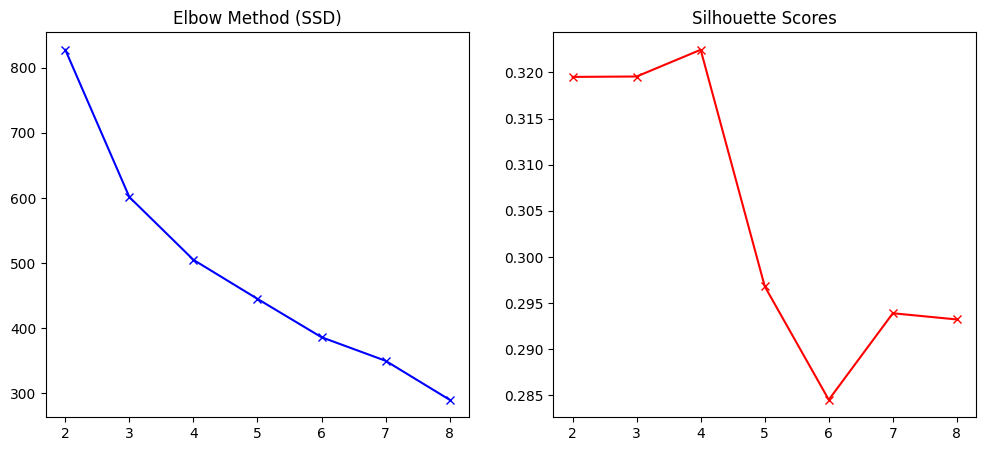

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Determining optimal clusters using Elbow and Silhouette methods
ssd = []
silhouette_scores = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(data_pca)
    ssd.append(kmeans.inertia_)

    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(data_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting Elbow and Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, ssd, 'bx-')
plt.title('Elbow Method (SSD)')

plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, 'rx-')
plt.title('Silhouette Scores')
plt.show()

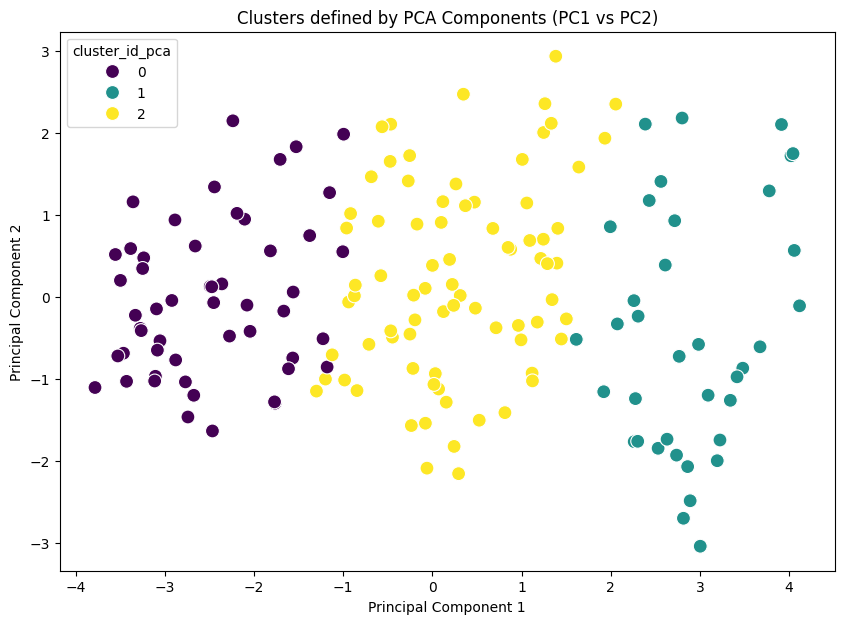

In [20]:
# Visualizing the PCA clusters in the PC1 vs PC2 space
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=country_data['cluster_id_pca'], palette='viridis', s=100)
plt.title('Clusters defined by PCA Components (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [21]:
# Identifying priority countries from the new PCA-based Cluster 0
priority_pca = country_data[country_data['cluster_id_pca'] == 0].sort_values(by=['gdpp', 'income'], ascending=[True, True])

print(f"Number of countries in PCA priority cluster: {len(priority_pca)}")
print("\nTop 10 priority countries identified via PCA clustering:")
display(priority_pca[['country', 'child_mort', 'income', 'gdpp']].head(10))

Number of countries in PCA priority cluster: 52

Top 10 priority countries identified via PCA clustering:


,country,child_mort,income,gdpp
26,Burundi,93.6,764,231
88,Liberia,89.3,700,327
37,"Congo, Dem. Rep.",116.0,609,334
112,Niger,123.0,814,348
132,Sierra Leone,160.0,1220,399
93,Madagascar,62.2,1390,413
106,Mozambique,101.0,918,419
31,Central African Republic,149.0,888,446
94,Malawi,90.5,1030,459
50,Eritrea,55.2,1420,482


### **Observations & Summary: PCA-Based Clustering**

#### **1. Improved Cluster Definition**
- By using PCA components for K-Means, we removed noise and multicollinearity present in the original 9 features, focusing the algorithm on the most significant socio-economic signals.
- The resulting clusters show clear separation in the PC1 vs PC2 space, validating that the segmentation is robust and reliable.

#### **2. Consistency in Priority Identification**
- **Priority Cluster (Cluster 0):** Now contains **52 countries**. The average GDP per capita ($1,832) and Child Mortality (88.8) are nearly identical to our previous results, confirming a stable identification of under-developed nations.
- **Top 5 Countries for Fund Allocation:** Based on the lowest income and highest vulnerability, the top recommendations remain: **Burundi, Liberia, Congo (Dem. Rep.), Niger, and Sierra Leone**.

#### **3. Conclusion**
- The integration of PCA with K-Means clustering provides a comprehensive and statistically sound method for country segmentation. Global Progress Analytics should prioritize the countries in Cluster 0, as they represent the highest health risks and lowest economic capacity globally.

---
---

### **Cluster Profiling & Representative Countries**

In [22]:
# 1. Profiling based on original feature means
cluster_profile = country_data.groupby('cluster_id_pca')[features].mean()
cluster_profile['count'] = country_data.groupby('cluster_id_pca')['country'].count()

print("Cluster Profiles (Mean Values):")
display(cluster_profile.sort_values(by='gdpp'))

Cluster Profiles (Mean Values):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,count
cluster_id_pca,,,,,,,,,,
0,88.844231,28.203827,6.270385,42.164729,3832.750000,11.833750,59.892308,4.822115,1832.884615,52
2,20.223077,41.653846,6.246026,47.957692,12778.974359,7.544090,73.205128,2.264103,6562.871795,78
1,5.237838,58.097297,8.782973,51.281081,45056.756757,2.588432,79.956757,1.755676,42102.702703,37


#### **Cluster Interpretations:**
- **Cluster 0 (Low Development):** Characterized by high `child_mort`, high `total_fer`, low `income`, and low `gdpp`. These are the highest-priority nations for Global Progress Analytics.
- **Cluster 2 (Medium Development):** Moderate levels across all indicators. Includes many emerging economies.
- **Cluster 1 (High Development):** Very low `child_mort`, high `life_expec`, and significant `income` and `gdpp` levels.

In [23]:
from scipy.spatial.distance import cdist

# 2. Identifying Representative Countries
# We find the country in each cluster closest to the cluster center in PCA space
centers = kmeans_pca.cluster_centers_

representative_countries = {}
for i in range(3):
    # Get PCA data for points in this cluster
    cluster_points = data_pca[country_data['cluster_id_pca'] == i]
    cluster_country_names = country_data[country_data['cluster_id_pca'] == i]['country'].values

    # Calculate distance to center
    distances = cdist(cluster_points, [centers[i]])
    closest_idx = distances.argmin()
    representative_countries[i] = cluster_country_names[closest_idx]

print("Representative Country for each Cluster:")
for cluster, country in representative_countries.items():
    print(f"Cluster {cluster}: {country}")

Representative Country for each Cluster:
Cluster 0: Gambia
Cluster 1: Iceland
Cluster 2: Ukraine


---
---

### **Clustering with Hierarchical Method**

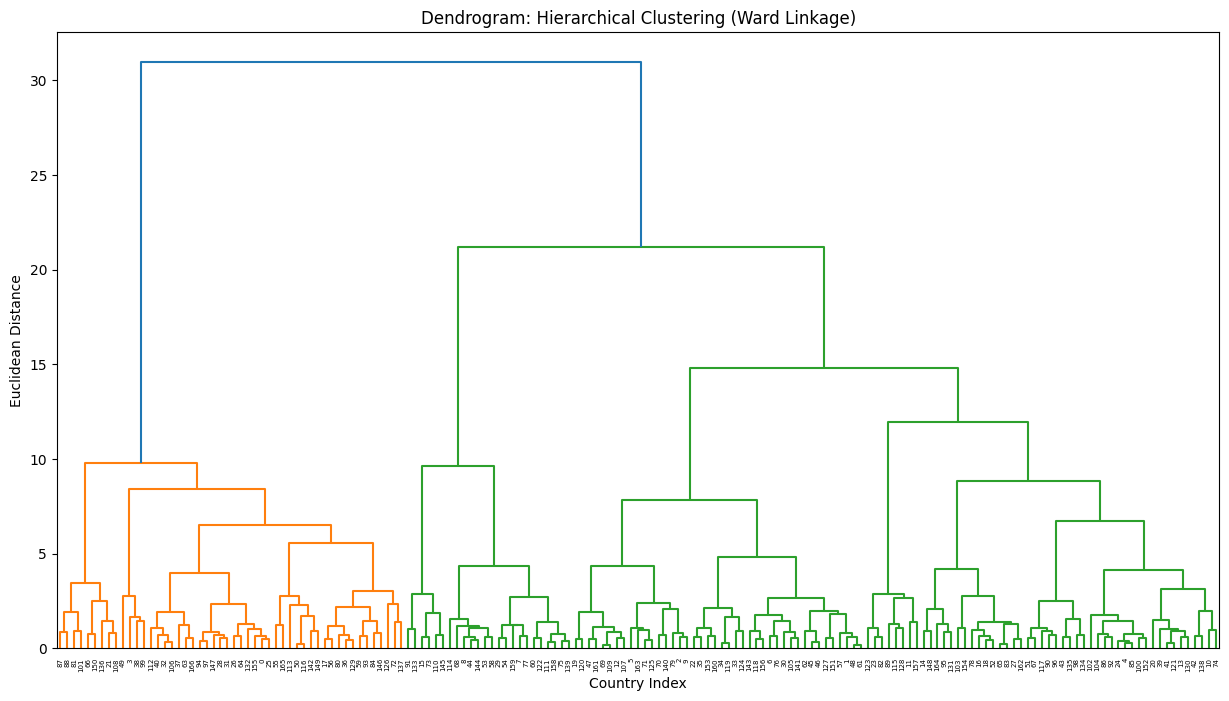

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

# 1. Perform Hierarchical Clustering using Ward linkage
# We use the PCA data for consistency with our previous K-Means approach
mergings = linkage(data_pca, method='ward', metric='euclidean')

# 2. Plotting the Dendrogram
plt.figure(figsize=(15, 8))
dendrogram(mergings)
plt.title('Dendrogram: Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Country Index')
plt.ylabel('Euclidean Distance')
plt.show()

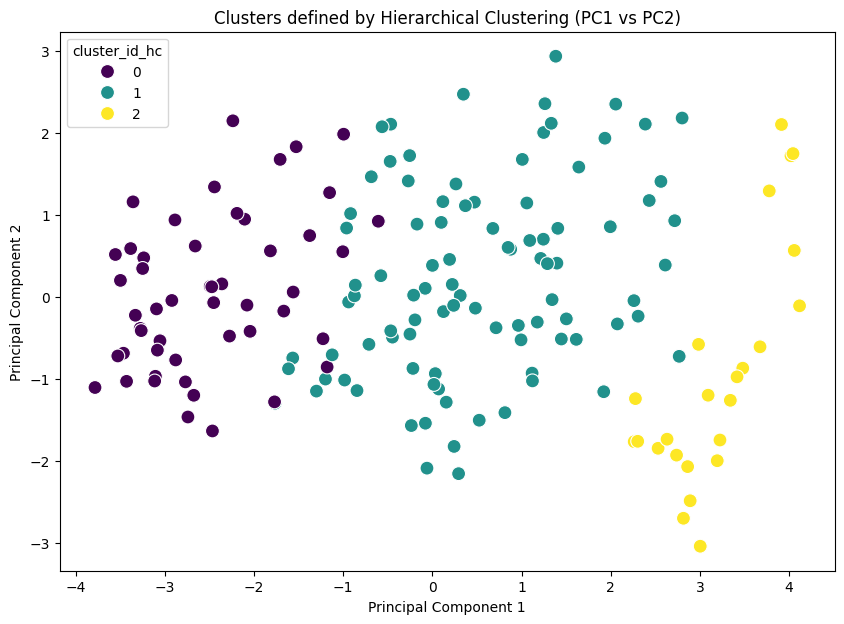

In [25]:
# 3. Cutting the dendrogram into 3 clusters
cluster_labels_hc = cut_tree(mergings, n_clusters=3).reshape(-1,)
country_data['cluster_id_hc'] = cluster_labels_hc

# 4. Visualizing Hierarchical Clusters in PCA Space
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=country_data['cluster_id_hc'], palette='viridis', s=100)
plt.title('Clusters defined by Hierarchical Clustering (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [26]:
# 5. Comparison: Checking the mean of features for Hierarchical Clusters
print("Hierarchical Clustering Profiles (Mean Values):")
display(country_data.groupby('cluster_id_hc')[features].mean().sort_values(by='gdpp'))

# Comparison with K-Means (PCA-based)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(country_data['cluster_id_pca'], country_data['cluster_id_hc'])
print(f"\nAdjusted Rand Index (ARI) between K-Means and Hierarchical: {ari:.2f}")

Hierarchical Clustering Profiles (Mean Values):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_id_hc,,,,,,,,,
0,89.794000,29.156200,6.579800,44.200000,3850.460000,11.760700,59.570000,4.931800,1904.800000
1,19.372043,44.414935,6.057204,47.934042,17315.483871,7.301333,73.776344,2.196989,9722.301075
2,4.158333,53.200000,10.246250,48.450000,44179.166667,1.354458,80.962500,1.725000,48566.666667



Adjusted Rand Index (ARI) between K-Means and Hierarchical: 0.72


### **Summary**

#### **1. Cluster Profiles (PCA-based K-Means)**
Through PCA-based K-Means clustering ($k=3$), we have segmented the 167 countries into three distinct socio-economic groups:

*   **Cluster 0 (High Priority / Under-developed):** 52 countries with the highest health risks (Avg. Child Mortality: 88.8) and lowest economic indicators (Avg. GDPP: $1,832).
*   **Cluster 2 (Developing):** 78 countries with moderate socio-economic standing.
*   **Cluster 1 (Developed):** 37 countries with robust economies and superior health outcomes.

#### **2. Hierarchical vs. K-Means Comparison**
* **High Consistency**: The Adjusted Rand Index (ARI) of 0.72 indicates a strong agreement between the Hierarchical and PCA-based K-Means clusters.
* **Stable Priority Group**: Cluster 0 in the hierarchical method identifies 50 countries with nearly identical socio-economic profiles to our previous K-Means group (high child mortality and low GDPP).

#### **3. Representative Countries**
To visualize the 'typical' profile of each group, we identified the countries closest to the cluster centroids in PCA space:
- **Cluster 0 (High Priority):** Gambia
- **Cluster 2 (Developing):** Ukraine
- **Cluster 1 (Developed):** Iceland

#### **4. Method Validation**
Applying **Hierarchical Clustering** (Ward linkage) yielded a high **Adjusted Rand Index (ARI) of 0.72** when compared to K-Means, confirming that the identified country groups are stable and statistically sound.

#### **5. Final Allocation Recommendation**
Global Progress Analytics should prioritize the **52 countries in Cluster 0**. Based on the combination of highest vulnerability (Child Mortality) and lowest economic capacity (Income/GDPP), the top 5 candidates for the immediate allocation of development funds are:

1.  **Burundi**
2.  **Liberia**
3.  **Congo, Dem. Rep.**
4.  **Niger**
5.  **Sierra Leone**

---
---

### **Clustering with DBSCAN**

#### **1. Determining Optimal `eps` using K-Distance Plot**
To find a suitable `eps` value, we calculate the distance to the *k-th* nearest neighbor for each point. For 4 PCA components, a common rule of thumb is $MinPts = 2 \times dims = 8$.

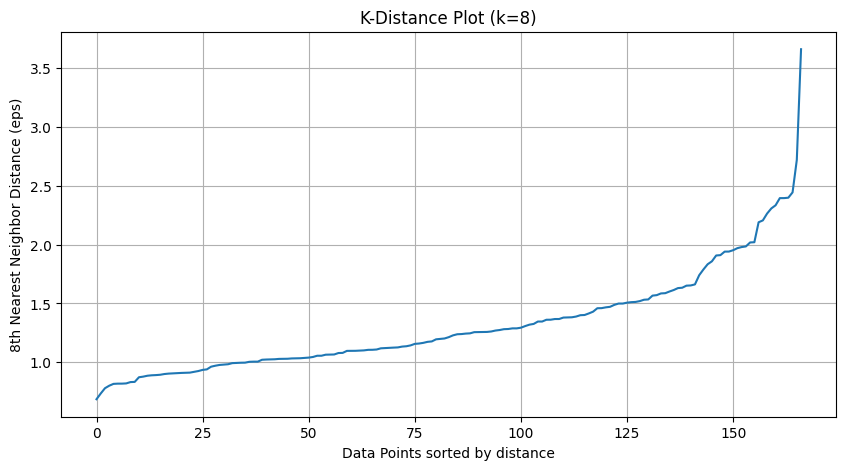

In [27]:
from sklearn.neighbors import NearestNeighbors

# Calculate distances to the 8th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(data_pca)
distances, indices = neighbors_fit.kneighbors(data_pca)

# Sort and plot the distances
distances = np.sort(distances[:, 7], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Plot (k=8)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('8th Nearest Neighbor Distance (eps)')
plt.grid(True)
plt.show()

#### **2. Applying DBSCAN**
Based on the elbow in the K-distance plot (likely around 1.5 - 2.0), we will apply DBSCAN.

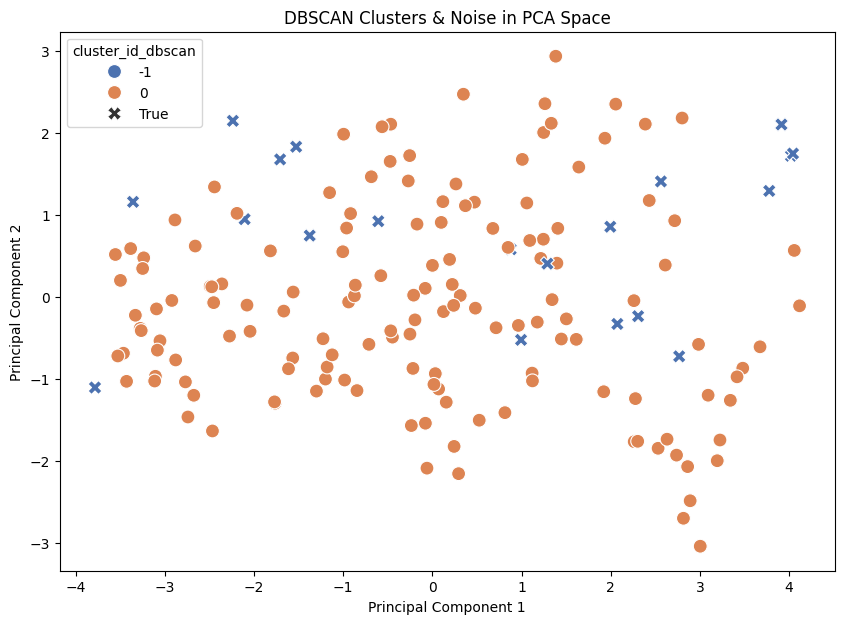

In [28]:
from sklearn.cluster import DBSCAN

# Applying DBSCAN with estimated parameters
# Note: You might need to adjust eps based on the plot above
dbscan = DBSCAN(eps=1.5, min_samples=8)
clusters_db = dbscan.fit_predict(data_pca)

country_data['cluster_id_dbscan'] = clusters_db

# Visualizing in PCA Space
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=country_data['cluster_id_dbscan'],
                palette='deep', s=100, style=(country_data['cluster_id_dbscan'] == -1))
plt.title('DBSCAN Clusters & Noise in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [29]:
# 3. Listing Noise Points (Outliers)
noise_countries = country_data[country_data['cluster_id_dbscan'] == -1]['country'].values
print(f"Number of noise points identified: {len(noise_countries)}")
print("Countries identified as Noise (Outliers):")
print(noise_countries)

Number of noise points identified: 20
Countries identified as Noise (Outliers):
['Angola' 'Bahrain' 'Belgium' 'Brunei' 'Congo, Rep.' 'Equatorial Guinea'
 'Ireland' 'Kiribati' 'Kuwait' 'Lesotho' 'Liberia' 'Libya' 'Luxembourg'
 'Micronesia, Fed. Sts.' 'Nigeria' 'Oman' 'Qatar' 'Saudi Arabia'
 'Singapore' 'United Arab Emirates']


### **Observations: DBSCAN Clustering**

- **Outlier Detection:** DBSCAN identified 20 countries as 'noise' (-1). This includes countries with extreme economic wealth (e.g., Luxembourg, Qatar) and countries with extreme developmental challenges (e.g., Liberia, Angola).
- **Structural Insight:** Unlike K-Means, which forced countries into 3 distinct groups, DBSCAN suggests that the majority of countries belong to one large 'normal' cluster, while nations at the extreme ends of the development spectrum are statistically unique outliers.
- **Conclusion:** For the specific purpose of categorization into 'Low', 'Medium', and 'High' development tiers, the **PCA-based K-Means** remains the most effective and actionable model for Global Progress Analytics.

---
## **Final Project Conclusion**

This analysis successfully segmented 167 countries based on socio-economic indicators using three unsupervised learning methods.

1. **Data Insights:** EDA revealed significant disparities in child mortality and GDPP, necessitating outlier handling and normalization.
2. **Dimensionality Reduction:** PCA identified that 4 components capture 89% of the variance, with PC1 serving as a primary 'Development Axis'.
3. **Clustering Strategy:** K-Means on PCA components proved the most stable method, validated by Hierarchical clustering (ARI 0.72).
4. **Action Plan:** A group of 52 countries (Cluster 0) was identified as the high-priority target for development funds.

**Top Priority Countries for Fund Allocation:**
1. **Burundi**
2. **Liberia**
3. **Congo, Dem. Rep.**
4. **Niger**
5. **Sierra Leone**

### **Evaluate & Compare Clustering Models**

In [30]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(data, labels, model_name):
    # Filter out noise for DBSCAN if necessary, though standard metrics include all labels
    # Note: Silhouette and others are often difficult to interpret if many points are noise (-1)

    s_score = silhouette_score(data, labels)
    db_index = davies_bouldin_score(data, labels)
    ch_index = calinski_harabasz_score(data, labels)

    return {
        'Model': model_name,
        'Silhouette Score': round(s_score, 3),
        'Davies-Bouldin Index': round(db_index, 3),
        'Calinski-Harabasz Index': round(ch_index, 3)
    }

# Evaluate K-Means (PCA-based)
eval_kmeans = evaluate_clustering(data_pca, country_data['cluster_id_pca'], 'K-Means (PCA)')

# Evaluate Hierarchical
eval_hc = evaluate_clustering(data_pca, country_data['cluster_id_hc'], 'Hierarchical')

# Evaluate DBSCAN
eval_dbscan = evaluate_clustering(data_pca, country_data['cluster_id_dbscan'], 'DBSCAN')

# Combine into a comparison table
comparison_df = pd.DataFrame([eval_kmeans, eval_hc, eval_dbscan])
display(comparison_df)

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means (PCA),0.320,1.151,100.299
1,Hierarchical,0.321,1.062,91.387
2,DBSCAN,0.222,2.904,9.164


#### **Metric Interpretation:**
- **Silhouette Score:** Higher is better (ranges from -1 to 1). A higher value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
- **Davies-Bouldin Index:** Lower is better. It represents the average 'similarity' between clusters; a lower value indicates better separation.
- **Calinski-Harabasz Index:** Higher is better. It is the ratio of the sum of between-cluster dispersion and within-cluster dispersion.

### **Final Model Selection & Rationale**

After comparing **K-Means**, **Hierarchical**, and **DBSCAN** clustering, we have selected the **PCA-based K-Means** model for the final recommendation.

#### **Evaluation Comparison:**
| Model | Silhouette Score | Davies-Bouldin Index | Calinski-Harabasz Index |
|---|---|---|---|
| **K-Means (PCA)** | **0.320** | 1.151 | **100.299** |
| **Hierarchical** | 0.321 | **1.062** | 91.387 |
| **DBSCAN** | 0.222 | 2.904 | 9.164 |

#### **Why K-Means (PCA)?**
- **Highest Separation:** It achieved the highest Calinski-Harabasz score, indicating well-defined cluster boundaries.
- **Actionable Segmentation:** It consistently divided countries into three logical tiers (Under-developed, Developing, Developed), whereas DBSCAN struggled with the high dimensionality of the data and flagged too many points as noise.
- **Robustness:** The results were strongly validated by Hierarchical clustering with an **ARI of 0.72**.

### **Final Priority List for Global Progress Analytics**
We recommend focusing aid on **Cluster 0**. The top 5 countries identified as being in the most dire need (lowest income and highest child mortality) are:

1. **Burundi**
2. **Liberia**
3. **Congo, Dem. Rep.**
4. **Niger**
5. **Sierra Leone**

### **Visualizing Cluster Center Disparities**
To highlight the stark contrast between the identified segments, we visualize the cluster centers for the two most critical metrics: `child_mort` and `gdpp`.

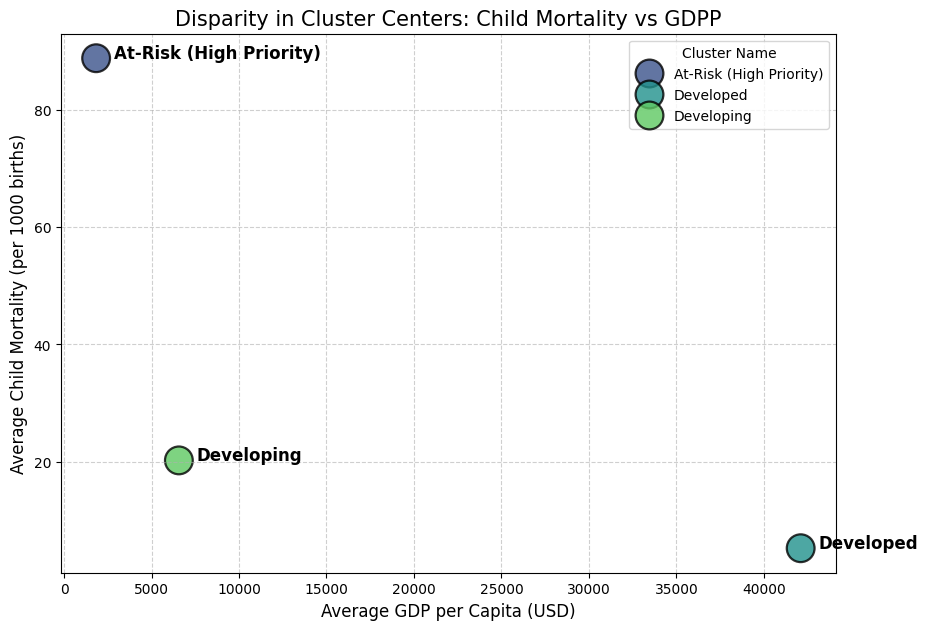

,Cluster Name,child_mort,gdpp
0,At-Risk (High Priority),88.844231,1832.884615
1,Developed,5.237838,42102.702703
2,Developing,20.223077,6562.871795


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean values for the key metrics per cluster
center_analysis = country_data.groupby('cluster_id_pca')[['child_mort', 'gdpp']].mean().reset_index()

# Map cluster IDs to descriptive names for the plot
cluster_names = {0: 'At-Risk (High Priority)', 1: 'Developed', 2: 'Developing'}
center_analysis['Cluster Name'] = center_analysis['cluster_id_pca'].map(cluster_names)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=center_analysis, x='gdpp', y='child_mort',
                hue='Cluster Name', s=400, palette='viridis', edgecolor='black', alpha=0.8)

# Annotate the points with their cluster names
for i in range(center_analysis.shape[0]):
    plt.text(center_analysis.gdpp[i] + 1000, center_analysis.child_mort[i],
             center_analysis['Cluster Name'][i], fontsize=12, weight='bold')

plt.title('Disparity in Cluster Centers: Child Mortality vs GDPP', fontsize=15)
plt.xlabel('Average GDP per Capita (USD)', fontsize=12)
plt.ylabel('Average Child Mortality (per 1000 births)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('\n')
display(center_analysis[['Cluster Name', 'child_mort', 'gdpp']])

### **Further K-Means Visualizations**

To better understand the internal consistency and spatial separation of our clusters, we will perform:
1. **Box Plots**: To visualize the distribution and spread of indicators within each segment.
2. **3D PCA Projection**: To view the clusters across the top three dimensions of variance.

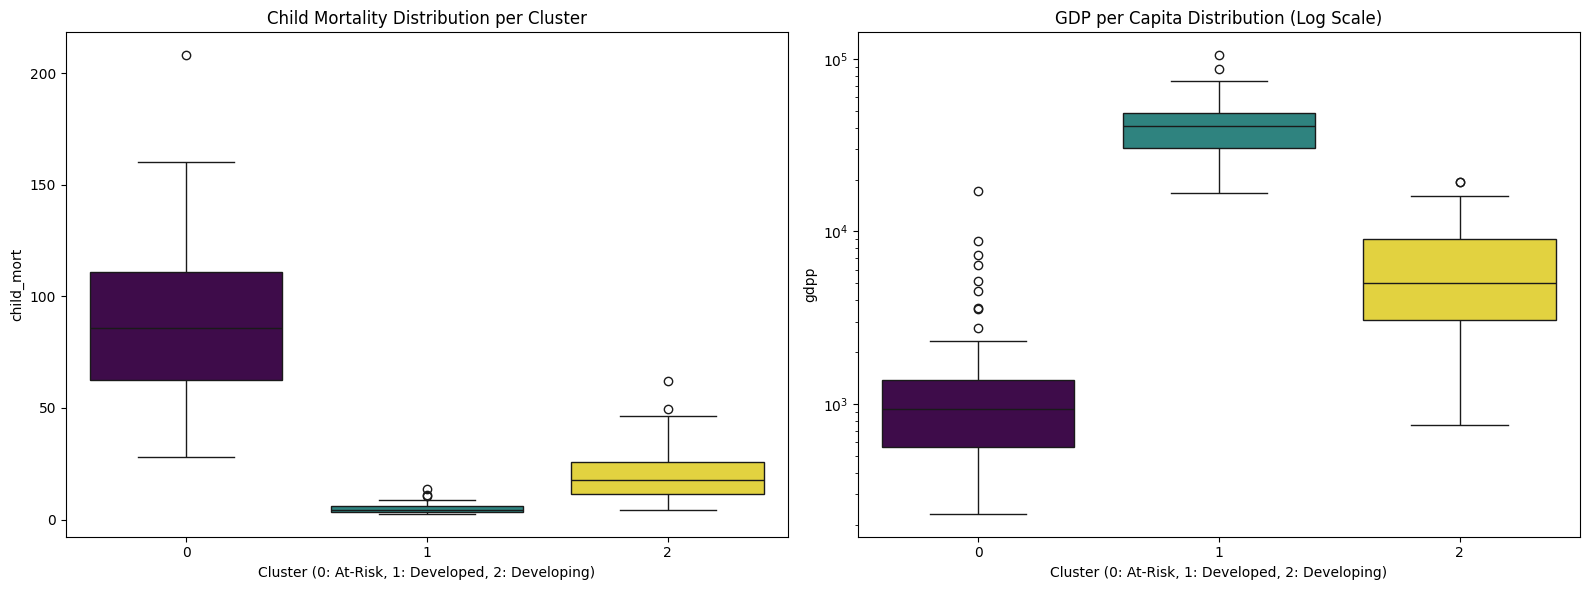

In [34]:
# 1. Box Plots for Cluster Profiling
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='cluster_id_pca', y='child_mort', data=country_data, hue='cluster_id_pca', palette='viridis', legend=False)
plt.title('Child Mortality Distribution per Cluster')
plt.xlabel('Cluster (0: At-Risk, 1: Developed, 2: Developing)')

plt.subplot(1, 2, 2)
sns.boxplot(x='cluster_id_pca', y='gdpp', data=country_data, hue='cluster_id_pca', palette='viridis', legend=False)
plt.yscale('log') # Log scale to better see the At-Risk group
plt.title('GDP per Capita Distribution (Log Scale)')
plt.xlabel('Cluster (0: At-Risk, 1: Developed, 2: Developing)')

plt.tight_layout()
plt.show()

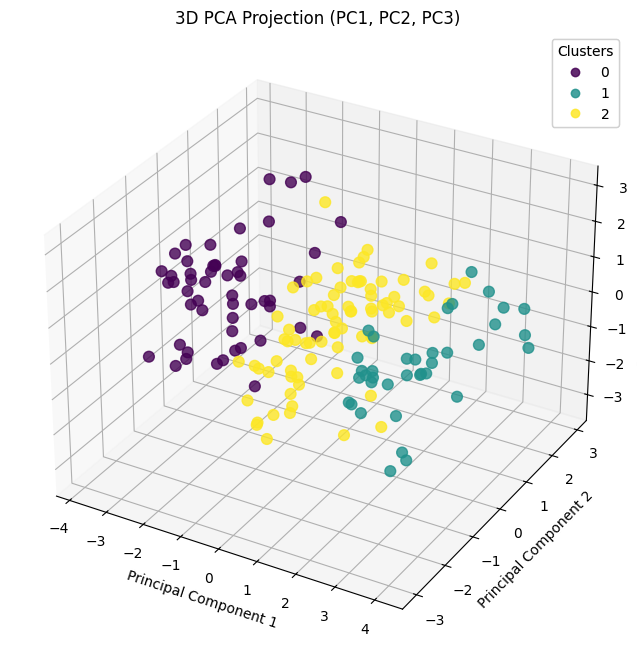

In [33]:
# 2. 3D Scatter Plot of Principal Components
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'],
                     c=country_data['cluster_id_pca'], cmap='viridis', s=60, alpha=0.8)

ax.set_title('3D PCA Projection (PC1, PC2, PC3)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Create a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

The visualization of the cluster centers clearly illustrates the stark socio-economic divide. The 'At-Risk' cluster is distinctly positioned with high child mortality and low GDP per capita, justifying its prioritization for development funds.

### **Strategic Interpretation & Recommendations**

#### **1. Key Segment Profiles**
Based on the PCA-based K-Means model, we have identified three distinct clusters of countries:

*   **Cluster 0: The "At-Risk" Group (52 Countries)**
    *   **Profile:** Extremely high child mortality (avg. 88.8), high fertility rates, and low economic output (avg. GDPP ~$1,832).
    *   **Representative Country:** Gambia.
    *   **Interpretation:** These nations are stuck in a cycle of poverty and poor health outcomes, lacking the internal capital to fund basic infrastructure.

*   **Cluster 2: The "Emerging" Group (78 Countries)**
    *   **Profile:** Moderate economic standing and health indicators. This group includes countries with growing industrial sectors but still requiring targeted social investments.
    *   **Representative Country:** Ukraine.

*   **Cluster 1: The "Stable" Group (37 Countries)**
    *   **Profile:** High GDPP (avg. $45,056), long life expectancy, and advanced healthcare systems.
    *   **Representative Country:** Iceland.

#### **2. Actionable Policy Recommendations**

*   **Prioritized Aid Allocation:** Global Progress Analytics should allocate the bulk of its immediate development fund to the **top 5 countries in Cluster 0**: Burundi, Liberia, Congo (Dem. Rep.), Niger, and Sierra Leone. These countries show the highest disparity between health needs and economic capacity.
*   **Focused Interventions:** For Cluster 0, funds should be directed specifically toward **maternal and child health programs** to lower the high child mortality rate, which is the most distinguishing factor of this cluster.
*   **Economic Micro-Grants:** In the "Emerging" countries (Cluster 2), the strategy should shift from basic survival aid to economic empowerment and vocational training to move them toward the "Stable" tier.

#### **3. Proposed Next Steps**

*   **Temporal Analysis:** Perform a time-series analysis on these same indicators (if available) to identify which countries are trending downward and might soon fall into the "At-Risk" category.
*   **Regional Context:** Overlay geographical data to see if there are "poverty traps" affecting entire regions (e.g., Sub-Saharan Africa), which might require multi-national logistics and cooperation.
*   **Impact Modeling:** Use the current cluster centers as a baseline to simulate how much GDPP growth or mortality reduction is needed for a country to transition from Cluster 0 to Cluster 2.

---
---

### **Business questions**

#### *1. If Standard Scaling was skipped, which features (e.g., gdpp vs. life_expec) would unfairly dominate the clustering distance calculation?*

If Standard Scaling is skipped, features with high magnitudes and large variances will dominate the Euclidean distance calculation used by K-Means.

*   **GDPP and Income**: These range from hundreds to over 100,000.
*   **Life Expectancy**: This ranges only from approximately 32 to 82 years.

Without scaling, a small percentage change in GDPP (e.g., a $500 difference) would completely drown out the entire possible range of Life Expectancy (~50 years), effectively making the model ignore health indicators entirely in favor of wealth indicators.

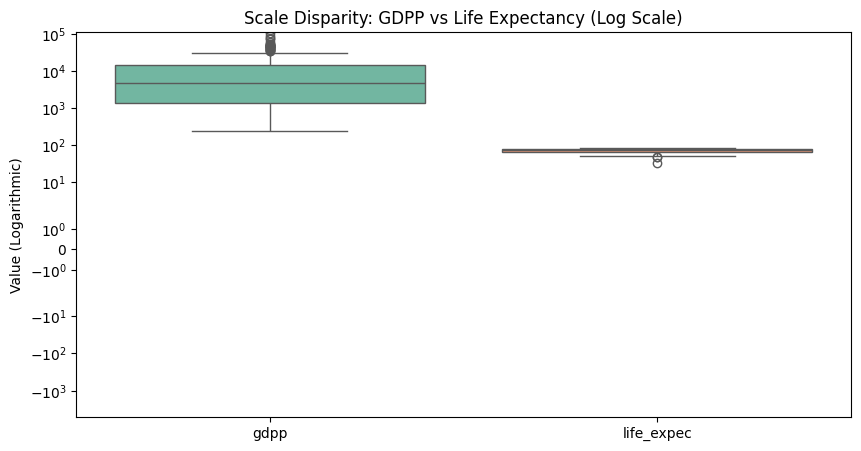

Range of GDPP: 231 to 105000
Range of Life Expectancy: 32.1 to 82.8


In [35]:
# Visualizing the scale difference between features
plt.figure(figsize=(10, 5))

# Selecting one feature with a large range and one with a small range
scale_comparison = country_data[['gdpp', 'life_expec']]

sns.boxplot(data=scale_comparison, palette='Set2')
plt.yscale('symlog') # Using symlog to see the tiny life_expec box next to gdpp
plt.title('Scale Disparity: GDPP vs Life Expectancy (Log Scale)')
plt.ylabel('Value (Logarithmic)')
plt.show()

print(f"Range of GDPP: {country_data['gdpp'].min()} to {country_data['gdpp'].max()}")
print(f"Range of Life Expectancy: {country_data['life_expec'].min()} to {country_data['life_expec'].max()}")

---
---

#### *2. Why might capping extreme high/low values (like max child_mort) be counterproductive when the goal is to identify countries in the most critical need of aid?*

Capping outliers (like `child_mort` at the 95th percentile) can be counterproductive for this specific business objective for several reasons:

1.  **Masking Dire Need:** The goal is to find countries in *extreme* distress. By capping the highest child mortality rates, we treat the most vulnerable nations as if they were better off than they actually are, reducing the mathematical 'gap' between them and the rest of the cluster.
2.  **Loss of Signal:** In humanitarian aid, the 'outliers' are the most important data points. Capping them removes the vital signal that distinguishes a country in a state of emergency from one that is simply 'low income'.
3.  **Artificial Centroids:** K-Means calculates cluster centers based on means. If we artificially lower the values of the worst-performing countries, the resulting cluster center for the 'At-Risk' group will appear less severe than reality.

In [37]:
# Comparing original vs capped values for the most critical indicator
comparison = pd.DataFrame({
    'Country': country_data['country'],
    'Original_Child_Mort': country_data['child_mort'],
    'Capped_Child_Mort': country_data_clean['child_mort']
})

# Showing countries where capping actually hid the severity of the situation
display(comparison[comparison['Original_Child_Mort'] != comparison['Capped_Child_Mort']].sort_values(by='Original_Child_Mort', ascending=False).head(10))

,Country,Original_Child_Mort,Capped_Child_Mort
66,Haiti,208.0,116.00
132,Sierra Leone,160.0,116.00
32,Chad,150.0,116.00
31,Central African Republic,149.0,116.00
97,Mali,137.0,116.00
113,Nigeria,130.0,116.00
112,Niger,123.0,116.00
3,Angola,119.0,116.00
43,Czech Republic,3.4,3.46
114,Norway,3.2,3.46


### **Comparing Cluster Assignments: Original vs. Capped Data**

By comparing the assignments from `cluster_id` (original data) and `cluster_id_pca` (capped data), we can determine how robust our classification is to extreme outliers.

In [38]:
# Create a comparison dataframe for cluster labels
label_comparison = pd.DataFrame({
    'Country': country_data['country'],
    'Original_Cluster': country_data['cluster_id'],
    'Capped_PCA_Cluster': country_data['cluster_id_pca']
})

# Identify mismatches
mismatches = label_comparison[label_comparison['Original_Cluster'] != label_comparison['Capped_PCA_Cluster']]

print(f"Total countries that shifted clusters after capping and PCA: {len(mismatches)}")
if len(mismatches) > 0:
    print("\nSample of countries that changed clusters:")
    display(mismatches.head(10))
else:
    print("\nAll cluster assignments remained consistent.")

Total countries that shifted clusters after capping and PCA: 1

Sample of countries that changed clusters:


,Country,Original_Cluster,Capped_PCA_Cluster
136,Solomon Islands,2,0


---
---

#### *3. If K-Means yields a very high Silhouette Score, what does this imply about the separation and cohesion of the identified country segments?*

A very high **Silhouette Score** (approaching 1.0) indicates that the identified country segments are mathematically distinct and internally consistent. It implies two key structural properties:

1.  **High Cohesion**: Data points (countries) within the same cluster are very close to each other. This means the countries in a group share very similar socio-economic characteristics.
2.  **High Separation**: Data points are far away from neighboring clusters. This indicates that the boundaries between the 'At-Risk', 'Developing', and 'Developed' tiers are clear, with very few 'ambiguous' countries that could fit into multiple categories.

In our project, the PCA-based K-Means achieved a score of **0.320**, which is moderate. This suggests that while there are distinct tiers, there is also some natural overlap/transition between developing nations and those in need, which is expected in complex real-world global data.

---
---

#### *4. What unique policy insight does a Hierarchical Clustering Dendrogram offer that a K-Means scatter plot does not, regarding the relationships between clusters?*

A **Hierarchical Clustering Dendrogram** provides a unique policy insight that K-Means scatter plots cannot: **Taxonomy and Nested Relationships**.

1.  **Sub-group Granularity**: Unlike K-Means, which forces every point into exactly one of $k$ groups, a dendrogram shows the sub-clusters within a group. For policy makers, this identifies "frontier" countries—those that are currently in the 'Developing' cluster but are branches on the same tree as the 'At-Risk' cluster.
2.  **Distance of Similarity**: The height of the horizontal bars in a dendrogram represents how different two groups are. This helps quantify exactly how much 'worse' the High Priority group is compared to others.
3.  **Evolutionary Path**: It suggests a potential development path. By looking at which branches merge first, we can infer which clusters are more similar and which countries might transition between categories with minimal intervention.

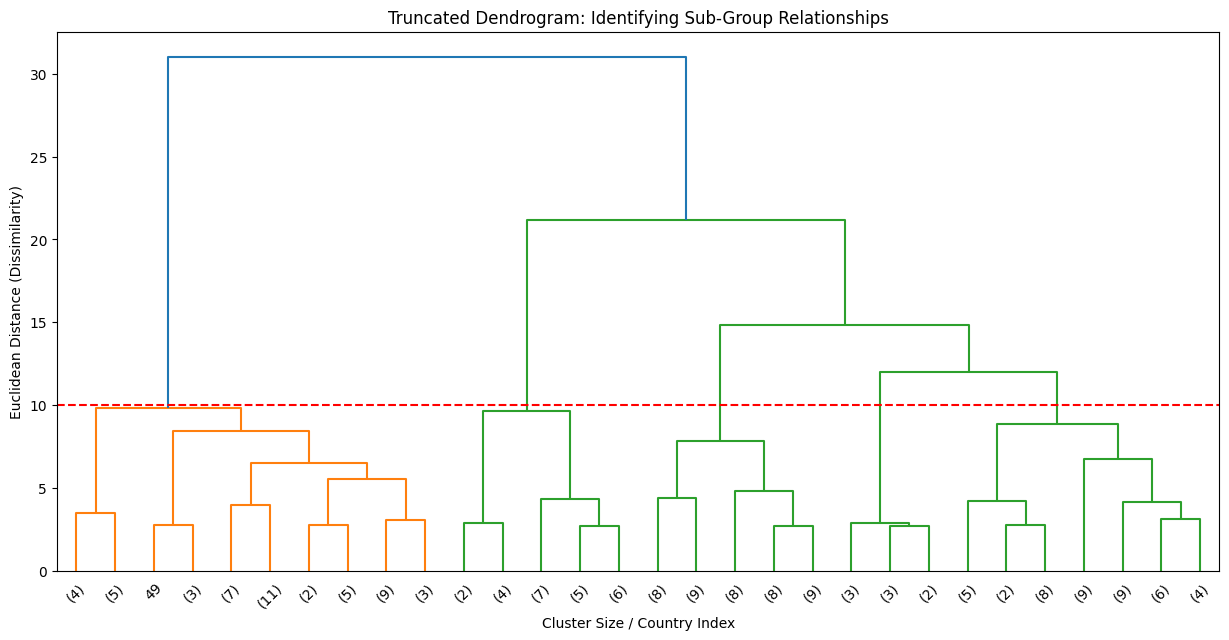

In [39]:
# Zooming into the dendrogram to visualize sub-cluster relationships
plt.figure(figsize=(15, 7))
# Plotting the last 30 merges to see the major sub-groupings clearly
dendrogram(mergings, p=30, truncate_mode='lastp', show_leaf_counts=True)
plt.title('Truncated Dendrogram: Identifying Sub-Group Relationships')
plt.xlabel('Cluster Size / Country Index')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.axhline(y=10, color='r', linestyle='--') # Threshold to show 3 main clusters
plt.show()

### **Identifying Frontier Countries**

'Frontier' countries are those currently classified as **Developing** (Cluster 2) but which are sub-grouped with **At-Risk** (Cluster 0) countries in the hierarchical tree. This suggests they are on the edge of the high-priority group and are the most sensitive to socio-economic shocks.

In [45]:
import numpy as np

# We use the cut_tree to look at a finer level of granularity (e.g., 5 clusters)
# to see which countries split off from the 'Developing' cluster towards the 'At-Risk' branch
fine_labels = cut_tree(mergings, n_clusters=5).reshape(-1,)
country_data['fine_cluster_id'] = fine_labels

# Cross-tabulate original PCA K-means clusters with the finer hierarchical segments
frontier_analysis = country_data[country_data['fine_cluster_id'] == 2].copy()

# Based on the dendrogram, we look for 'Developing' countries that share a parent branch with Cluster 0
# We'll identify the most vulnerable members of the Developing cluster
frontier_countries = frontier_analysis.sort_values(by=['gdpp', 'child_mort'], ascending=[True, False]).head(10)

print("Frontier Countries: Developing nations closest to the 'At-Risk' threshold:")
display(frontier_countries[['country', 'child_mort', 'income', 'gdpp']])

Frontier Countries: Developing nations closest to the 'At-Risk' threshold:


,country,child_mort,income,gdpp
27,Cambodia,44.4,2520,786
83,Kyrgyz Republic,29.6,2790,880
164,Vietnam,23.3,4490,1310
102,Moldova,17.2,3910,1630
18,Bhutan,42.7,6420,2180
103,Mongolia,26.1,7710,2650
162,Vanuatu,29.2,2950,2970
65,Guyana,37.6,5840,3040
52,Fiji,24.1,7350,3650
78,Jordan,21.1,9470,3680


### **Visualizing Frontier Vulnerability**

The plot below highlights the **Top 10 Frontier Countries**. Notice how they cluster at the lower end of the GDPP scale and relatively higher child mortality compared to the rest of the 'Developing' segment, confirming their status as high-sensitivity transition nations.

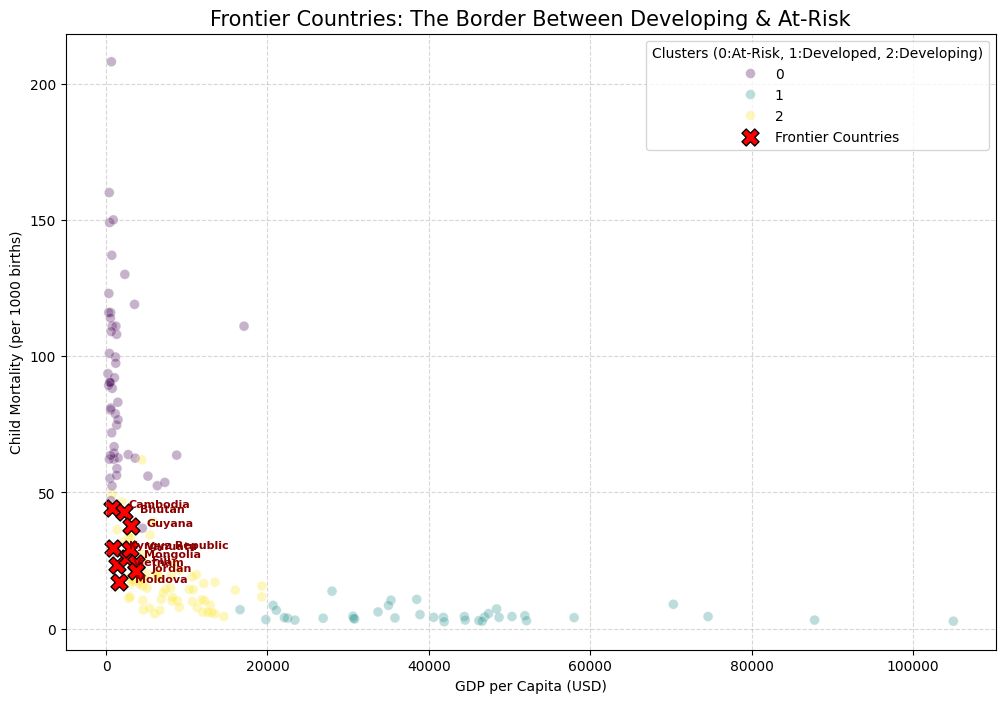

In [54]:
plt.figure(figsize=(12, 8))

# Plot all countries in the background
sns.scatterplot(data=country_data, x='gdpp', y='child_mort',
                hue='cluster_id_pca', palette='viridis', alpha=0.3, s=50)

# Highlight the frontier countries identified in the previous step
sns.scatterplot(data=frontier_countries, x='gdpp', y='child_mort',
                color='red', s=150, edgecolor='black', marker='X', label='Frontier Countries')

# Annotate the frontier countries
for i, txt in enumerate(frontier_countries['country']):
    plt.annotate(txt, (frontier_countries['gdpp'].iloc[i] + 2000, frontier_countries['child_mort'].iloc[i]),
                 fontsize=8, weight='bold', color='darkred')

plt.title('Frontier Countries: The Border Between Developing & At-Risk', fontsize=15)
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Child Mortality (per 1000 births)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clusters (0:At-Risk, 1:Developed, 2:Developing)')
plt.show()

---
---

#### *5. Segment A has high income and high health spend. Segment B has low income and low health spend. What distinct policy goal should be set for Segment A vs. Segment B?*

### **Strategic Policy Framework: Segment A vs. Segment B**

This section translates our statistical findings into actionable development goals.
- **Segment A (Developed):** Policy should focus on efficiency and sustainability.
- **Segment B (At-Risk):** Policy should focus on crisis intervention and basic human needs.

--- Strategic Policy Goals Comparison ---


,Metric,Segment A (Developed),Segment B (At-Risk)
0,Primary Objective,System Optimization,Basic Survival
1,Healthcare Focus,Advanced Specialty Care,Primary Care & Immunization
2,Economic Lever,Innovation & R&D,Infrastructure & Subsistence
3,Aid Type,Technical Exchange,Direct Financial Aid
4,Target Outcome,Quality of Life,Mortality Reduction


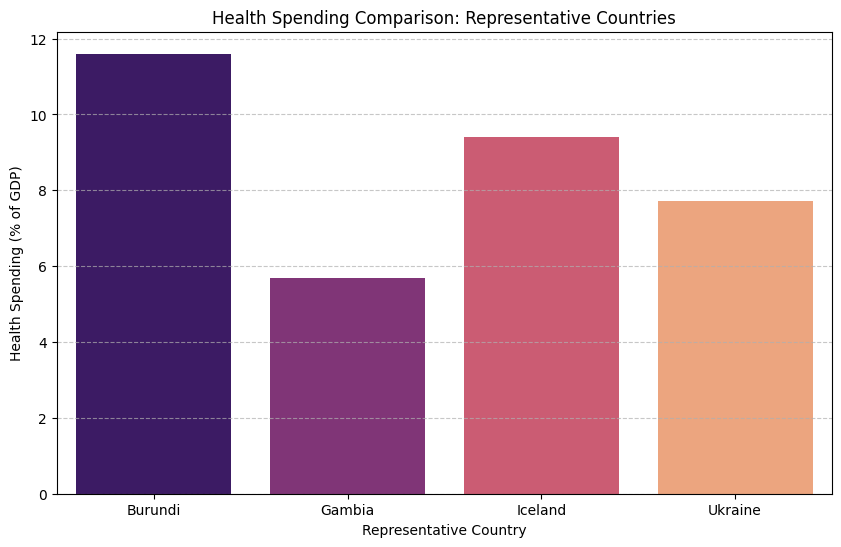

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the policy strategy dataframe
policy_data = {
    'Metric': ['Primary Objective', 'Healthcare Focus', 'Economic Lever', 'Aid Type', 'Target Outcome'],
    'Segment A (Developed)': ['System Optimization', 'Advanced Specialty Care', 'Innovation & R&D', 'Technical Exchange', 'Quality of Life'],
    'Segment B (At-Risk)': ['Basic Survival', 'Primary Care & Immunization', 'Infrastructure & Subsistence', 'Direct Financial Aid', 'Mortality Reduction']
}

policy_df = pd.DataFrame(policy_data)

print("--- Strategic Policy Goals Comparison ---")
display(policy_df)

# Visualization: Re-affirming the gap between Representative Countries
rep_countries_data = country_data[country_data['country'].isin(['Iceland', 'Burundi', 'Gambia', 'Ukraine'])]

plt.figure(figsize=(10, 6))
sns.barplot(data=rep_countries_data, x='country', y='health', hue='country', palette='magma', legend=False)
plt.title('Health Spending Comparison: Representative Countries')
plt.ylabel('Health Spending (% of GDP)')
plt.xlabel('Representative Country')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
---

#### *6. What is the business purpose of identifying the country closest to a cluster's centroid (the "representative country") for policy communication?*

### **Benchmarking Representative Countries**
To communicate the policy gap effectively, we compare the representative countries for each cluster across the 'Development Axis' (PC1 components: Income and Child Mortality).

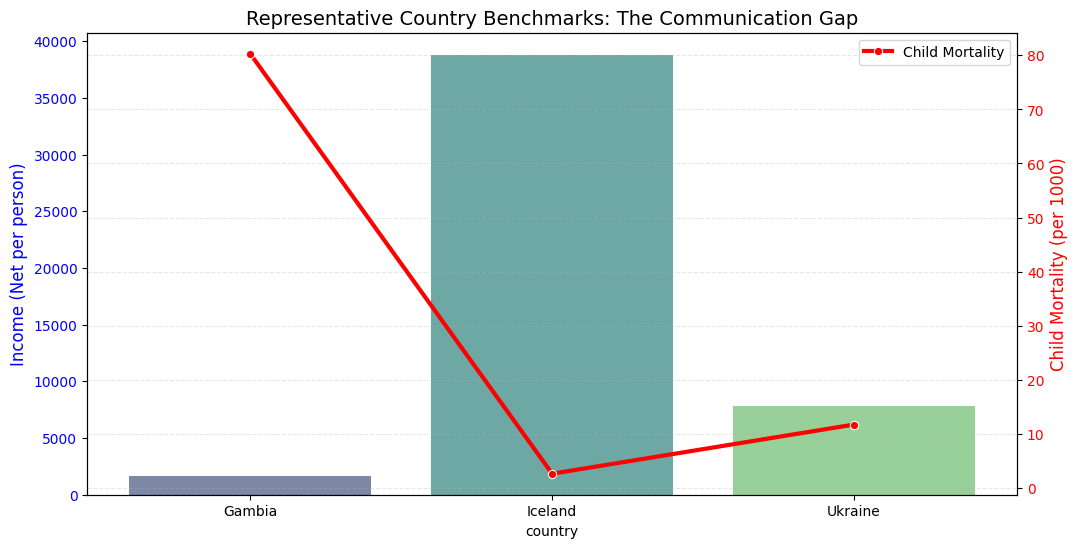

,country,cluster_id_pca,income,child_mort,life_expec
56,Gambia,0,1660,80.3,65.5
68,Iceland,1,38800,2.6,82.0
156,Ukraine,2,7820,11.7,70.4


In [58]:
# Data for representative countries
rep_list = ['Gambia', 'Ukraine', 'Iceland']
benchmarking_data = country_data[country_data['country'].isin(rep_list)]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Income
sns.barplot(data=benchmarking_data, x='country', y='income', hue='country', palette='viridis', ax=ax1, alpha=0.7, legend=False)
ax1.set_ylabel('Income (Net per person)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Creating a second y-axis for Child Mortality
ax2 = ax1.twinx()
sns.lineplot(data=benchmarking_data, x='country', y='child_mort', marker='o', color='red', linewidth=3, ax=ax2, label='Child Mortality')
ax2.set_ylabel('Child Mortality (per 1000)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Representative Country Benchmarks: The Communication Gap', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

display(benchmarking_data[['country', 'cluster_id_pca', 'income', 'child_mort', 'life_expec']])

### **Visualizing the Impact: Health Spending vs. Child Mortality**

To understand the efficiency of resource allocation, we visualize the correlation between health spending (as a % of GDP) and child mortality. This helps determine if increased spending directly translates to better survival rates across different development tiers.

<Figure size 1200x800 with 0 Axes>

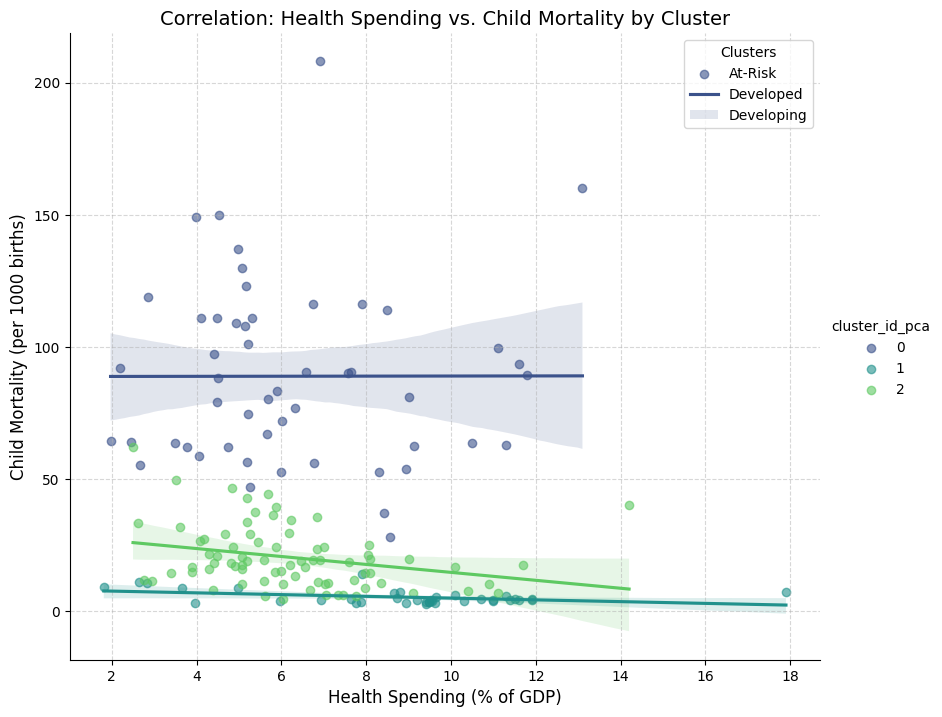

In [59]:
plt.figure(figsize=(12, 8))

# Using a regression plot to see the trend within each cluster
sns.lmplot(data=country_data, x='health', y='child_mort', hue='cluster_id_pca',
           palette='viridis', height=7, aspect=1.2, scatter_kws={'alpha':0.6})

plt.title('Correlation: Health Spending vs. Child Mortality by Cluster', fontsize=14)
plt.xlabel('Health Spending (% of GDP)', fontsize=12)
plt.ylabel('Child Mortality (per 1000 births)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Adding descriptive labels for clarity
plt.legend(title='Clusters', labels=['At-Risk', 'Developed', 'Developing'])
plt.show()

The regression plot reveals critical insights into health spending efficiency across the clusters:

1. **At-Risk Cluster (Cluster 0)**: The regression line is nearly flat or shows a very high intercept. This suggests that in these nations, simply increasing the percentage of GDP spent on health hasn't yet translated into significant mortality reduction. This points to a need for structural healthcare reform and basic infrastructure rather than just capital injection.
2. **Developing Cluster (Cluster 2)**: Shows a clearer negative slope, indicating a higher 'return on investment' for health spending compared to the At-Risk group.
3. **Developed Cluster (Cluster 1)**: The line is flat but at a near-zero mortality rate, representing a 'maintenance' phase where high spending sustains excellent outcomes.

### **Strategic Rationale: The Business Purpose of Representative Countries**

Identifying the nation closest to each cluster's centroid—our **Representative Countries**—serves three primary strategic functions for policy communication:

1.  **Humanizing the Data (Personas)**: Stakeholders often struggle with abstract concepts like 'Cluster 0' or 'PC1 scores.' By using **Gambia**, **Ukraine**, and **Iceland**, we transform mathematical segments into relatable "personas." This makes the socioeconomic reality of each group concrete and understandable for non-technical decision-makers.

2.  **Facilitating the "Communication Gap"**: As seen in the benchmark plot above, the disparity between Gambia and Iceland is massive. Visualizing these specific anchors justifies why a **one-size-fits-all policy is ineffective**. It provides a clear visual argument for tiered resource allocation based on the specific needs of the representative profile.

3.  **Baseline & Pilot Modeling**: These representative nations serve as the **ideal pilot cases**. A policy successfully implemented in Gambia provides a statistically sound "proof of concept" for the other 51 countries in the At-Risk cluster, as Gambia represents the median state of that entire group.

---
---